# Análisis de Eficiencia Energética en Edificios Industriales

## Descripción
Este proyecto analiza la eficiencia energética en edificios industriales 
a partir de variables físicas como compacidad, área superficial y altura. 
Los datos provienen del dataset ENB2012 del repositorio UCI Machine Learning, 
que contiene 768 registros de simulaciones energéticas en distintos tipos 
de edificaciones.

La eficiencia energética es clave en la industria porque los sistemas de 
climatización, iluminación y maquinaria pesada representan gran parte del 
gasto operativo. Detectar ineficiencias genera un retorno de inversión directo 
al reducir la facturación mensual y disminuir la huella de carbono.

## Objetivo
Identificar qué variables físicas de un edificio tienen mayor impacto en 
el consumo energético de calefacción y refrigeración, con el fin de apoyar 
la toma de decisiones orientadas a la sostenibilidad industrial.

Este análisis es relevante para empresas como Holcim, cuya meta corporativa 
es alcanzar cero emisiones netas y usar energía 100% renovable en 
Latinoamérica. A través de tecnologías propias como AIRIUM, un sistema de 
aislamiento que reduce hasta un 20% el consumo por climatización, Holcim 
tiene la oportunidad de aplicar estos hallazgos directamente en sus 
edificaciones y ofrecer soluciones al mercado.

## Dataset
- **Fuente:** UCI Machine Learning Repository - ENB2012
- **Registros:** 768
- **Variables:** 10

- **Variables de entrada:**
    - Compacidad
    - Área superficial
    - Área de muros
    - Área de techo
    - Altura
    - Orientación
    - Área acristalada
    - Distribución de vidrio

- **Variables objetivo:**
    - Carga de calefacción (kWh/m²)
    - Carga de refrigeración (kWh/m²)

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_excel(r"C:\Users\Loany\Documentos\trabajos\analisis-consumo-cementero\ENB2012_data.xlsx")

# Renombrar columnas
df.columns = [
    'compacidad', 'area_superficial', 'area_muros', 'area_techo',
    'altura', 'orientacion', 'area_acristalada', 'distribucion_vidrio',
    'carga_calefaccion', 'carga_refrigeracion'
]

print(" Datos cargados:", df.shape)
print("\n¿Valores nulos?", df.isnull().sum().sum())
print("¿Duplicados?", df.duplicated().sum())
df.head()

 Datos cargados: (768, 10)

¿Valores nulos? 0
¿Duplicados? 0


,compacidad,area_superficial,area_muros,area_techo,altura,orientacion,area_acristalada,distribucion_vidrio,carga_calefaccion,carga_refrigeracion
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


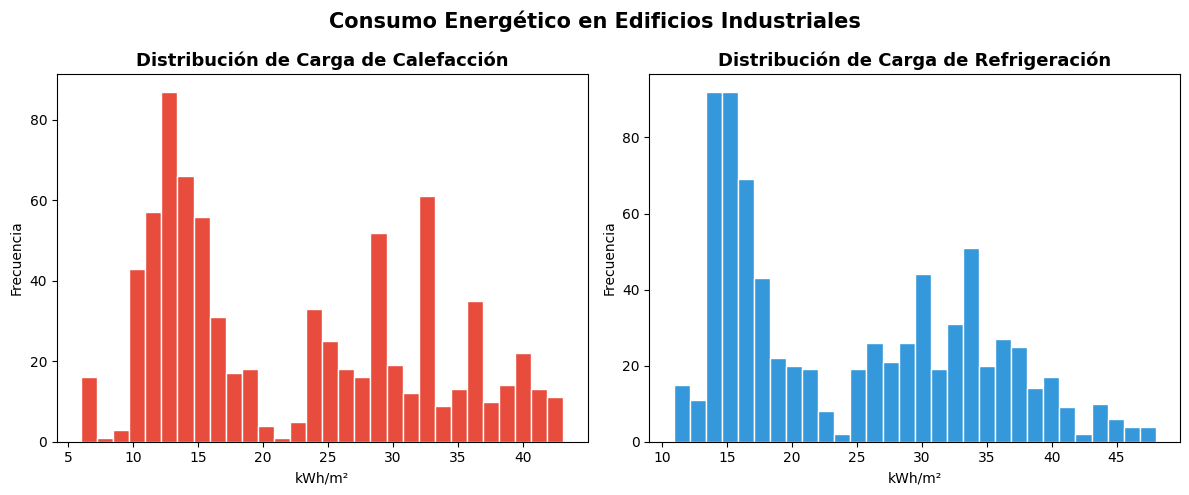

 Gráfica 1 guardada


In [26]:
# Gráfica 1 - Distribución de consumo energético
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['carga_calefaccion'], bins=30, color='#e74c3c', edgecolor='white')
axes[0].set_title('Distribución de Carga de Calefacción', fontsize=13, fontweight='bold')
axes[0].set_xlabel('kWh/m²')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['carga_refrigeracion'], bins=30, color='#3498db', edgecolor='white')
axes[1].set_title('Distribución de Carga de Refrigeración', fontsize=13, fontweight='bold')
axes[1].set_xlabel('kWh/m²')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Consumo Energético en Edificios Industriales', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Loany\Documentos\trabajos\analisis-consumo-cementero\grafica1_distribucion.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfica 1 guardada")

### Hallazgos - Distribución de Consumo Energético
- La carga de calefacción presenta valores concentrados entre 6 y 20 kWh/m², 
  con algunos edificios que superan los 35 kWh/m².
- La carga de refrigeración tiene una distribución más dispersa, 
  lo que indica mayor variabilidad en el consumo de enfriamiento.
- En promedio, la refrigeración representa un mayor consumo que la calefacción.

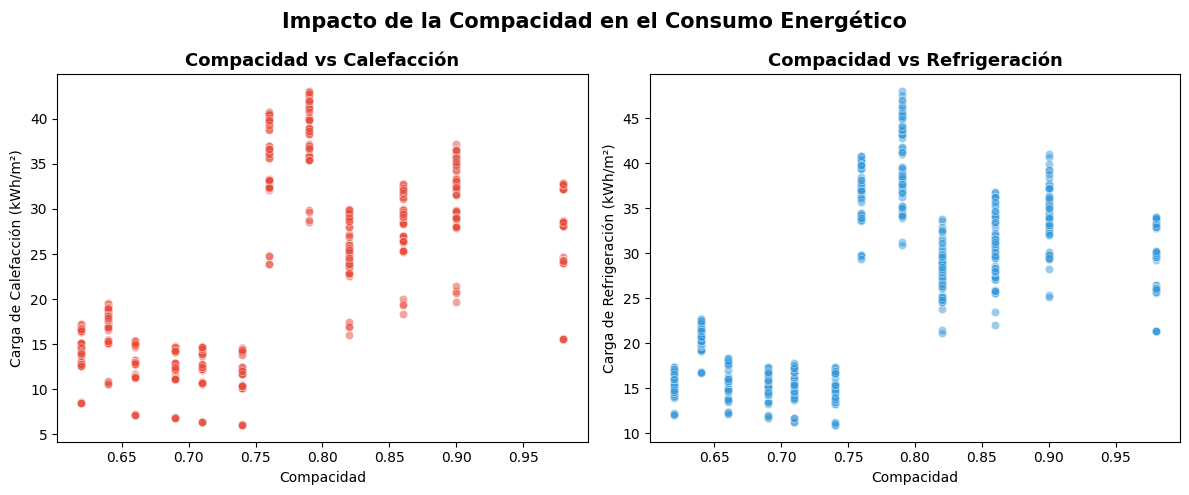

 Gráfica 2 guardada


In [27]:
# Gráfica 2 - Compacidad vs Consumo energético
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['compacidad'], df['carga_calefaccion'], 
                color='#e74c3c', alpha=0.5, edgecolors='white', linewidth=0.5)
axes[0].set_title('Compacidad vs Calefacción', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compacidad')
axes[0].set_ylabel('Carga de Calefacción (kWh/m²)')

axes[1].scatter(df['compacidad'], df['carga_refrigeracion'], 
                color='#3498db', alpha=0.5, edgecolors='white', linewidth=0.5)
axes[1].set_title('Compacidad vs Refrigeración', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Compacidad')
axes[1].set_ylabel('Carga de Refrigeración (kWh/m²)')

plt.suptitle('Impacto de la Compacidad en el Consumo Energético', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Loany\Documentos\trabajos\analisis-consumo-cementero\grafica2_compacidad.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfica 2 guardada")

### Hallazgos - Compacidad vs Consumo
- Se observa una relación positiva entre compacidad y consumo energético.
- Edificios con compacidad cercana a 0.77 presentan los mayores picos 
  de carga de calefacción.
- A mayor compacidad, mayor consumo tanto de calefacción como refrigeración.

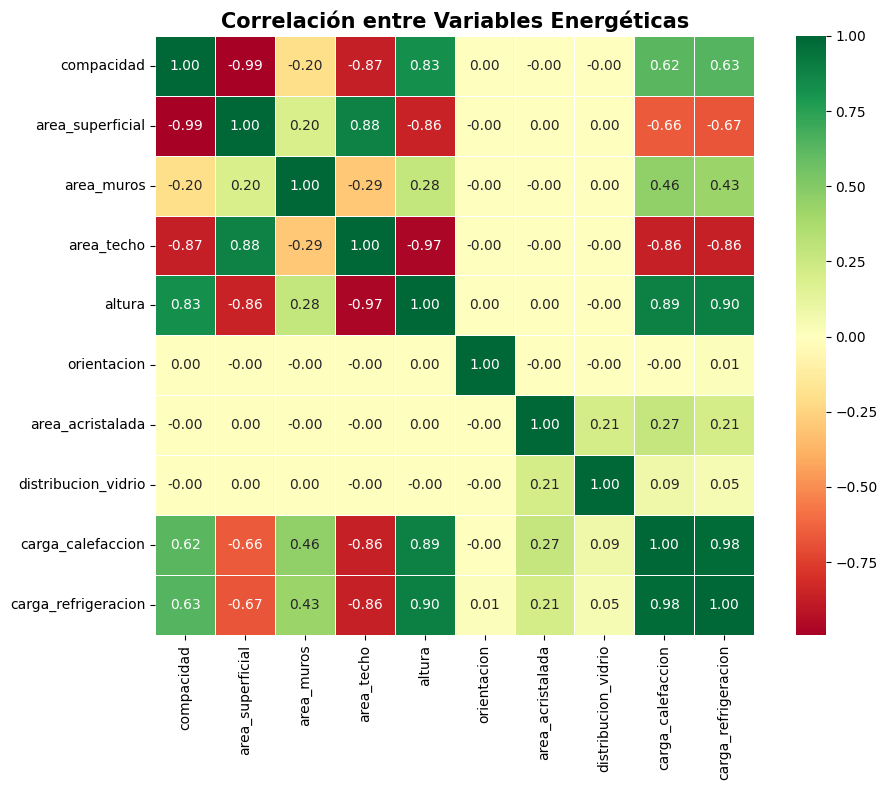

 Gráfica 3 guardada


In [28]:
# Gráfica 3 - Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(10, 8))

correlaciones = df.corr()

sns.heatmap(correlaciones, 
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlación entre Variables Energéticas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Loany\Documentos\trabajos\analisis-consumo-cementero\grafica3_correlaciones.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfica 3 guardada")

### Hallazgos - Correlación entre Variables
- La compacidad y el área superficial presentan la correlación más fuerte 
  con el consumo energético.
- Existe una correlación negativa entre área superficial y compacidad, 
  lo que indica que edificios más compactos tienen menor área superficial.
- Las variables de orientación y distribución de vidrio tienen 
  menor impacto en el consumo energético.

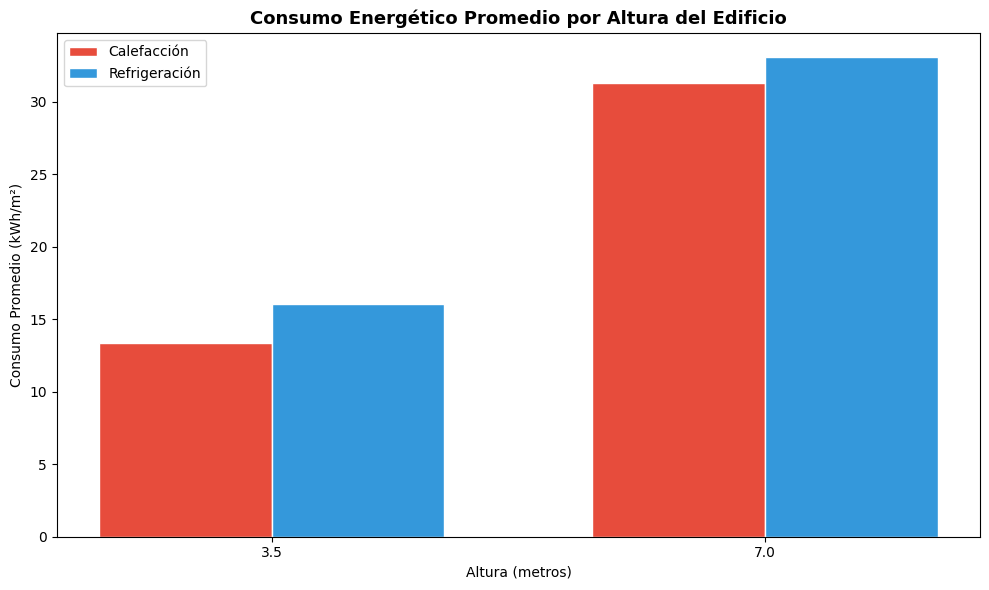

 Gráfica 4 guardada


In [29]:
# Gráfica 4 - Consumo promedio por altura del edificio
consumo_altura = df.groupby('altura')[['carga_calefaccion', 'carga_refrigeracion']].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(consumo_altura))
width = 0.35

ax.bar([i - width/2 for i in x], consumo_altura['carga_calefaccion'], 
       width, label='Calefacción', color='#e74c3c', edgecolor='white')
ax.bar([i + width/2 for i in x], consumo_altura['carga_refrigeracion'], 
       width, label='Refrigeración', color='#3498db', edgecolor='white')

ax.set_title('Consumo Energético Promedio por Altura del Edificio', fontsize=13, fontweight='bold')
ax.set_xlabel('Altura (metros)')
ax.set_ylabel('Consumo Promedio (kWh/m²)')
ax.set_xticks(x)
ax.set_xticklabels(consumo_altura['altura'])
ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\Loany\Documentos\trabajos\analisis-consumo-cementero\grafica4_altura.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfica 4 guardada")

### Hallazgos - Consumo por Altura
- Los edificios más altos (7 metros) presentan el mayor consumo 
  energético tanto en calefacción como en refrigeración.
- El consumo de refrigeración supera al de calefacción en todos 
  los niveles de altura.
- Edificios de menor altura (3.5 metros) son significativamente 
  más eficientes energéticamente.

# Conclusiones
-La **compacidad** es la variable más influyente en el consumo energetico.
Diseñar edificios con menor compacidad puede reducir significativamente el gasto energético.

-Se recomienda a Holcim **evitar construcciones de gran altura**, ya que los edificios de 7 metros presentan el mayor consumo, especialmente en regrigeración, lo que impacta negativamente tanto en costos operativos como en emisiones de carbono.

-El mayor gasto energético se concentra en **refrigeración**, por lo que integrar tecnologías de aislamiento como AIRLUM representaría un ahorro directo y medible.

## Proximos pasos
-Construir un modelo de Machine Learning que prediga el consumo energético de un edificio antes de su construcción, basándose en sus características físicas.

-Esto permitiría a Holcim tomar decisisones sostenibles desde la etapa de diseño, reduciendo costos y huella de carbono.

